# Data structure and features

In [1]:
import pandas as pd
import os
import glob
# podívej se co je uvnitř
train_files = glob.glob("train/**/*.csv", recursive=True)
test_files  = glob.glob("test/**/*.csv",  recursive=True)

print(f"Train files: {len(train_files)}")
print(f"Test files:  {len(test_files)}")

# načti jeden soubor
df = pd.read_csv(train_files[0])
print(df.head())
print(df.shape)
print(df.columns.tolist())


Train files: 11020
Test files:  6849
   index    mean_x    mean_y    mean_z         std_x     std_y     std_z  \
0      0 -0.467629 -0.537854  0.657240  3.733827e-03  0.007097  0.004734   
1      1 -0.466690 -0.547035  0.654931  1.115816e-16  0.005082  0.006511   
2      2 -0.467316 -0.535987  0.658472  3.080919e-03  0.005875  0.002188   
3      3 -0.468880 -0.533341  0.658472  5.455416e-03  0.000000  0.000000   
4      4 -0.470288 -0.533341  0.658472  6.616433e-03  0.000000  0.000000   

   label  file_id  
0      0        1  
1      0        1  
2      0        1  
3      0        1  
4      0        1  
(300, 9)
['index', 'mean_x', 'mean_y', 'mean_z', 'std_x', 'std_y', 'std_z', 'label', 'file_id']


# Submission format

In [2]:
sub = pd.read_csv("sample_submission.csv")
print(sub.head())
print(f"Number of rows: {len(sub)}")


      Id  Label
0  11021      0
1  11022      0
2  11023      0
3  11024      0
4  11025      0
Number of rows: 6849


# Class Distribution Analysis

In [3]:
import pandas as pd
import glob
import numpy as np

# načti všechna trénovací data
all_data = []
for f in train_files:
    df = pd.read_csv(f)
    all_data.append({
        'file_id': df['file_id'].iloc[0],
        'label': df['label'].iloc[0]
    })

meta_df = pd.DataFrame(all_data)
print(f"Total train files: {len(meta_df)}")

# přidej procenta
counts = meta_df['label'].value_counts().sort_index()
percentages = (counts / len(meta_df) * 100).round(2)

distribution = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages
})

print(f"\nActivity distribution:")
print(distribution)


Total train files: 11020

Activity distribution:
       Count  Percentage (%)
label                       
0       4643           42.13
1       4695           42.60
2        358            3.25
3        656            5.95
4        142            1.29
5        526            4.77


# Class Imbalance Visualization

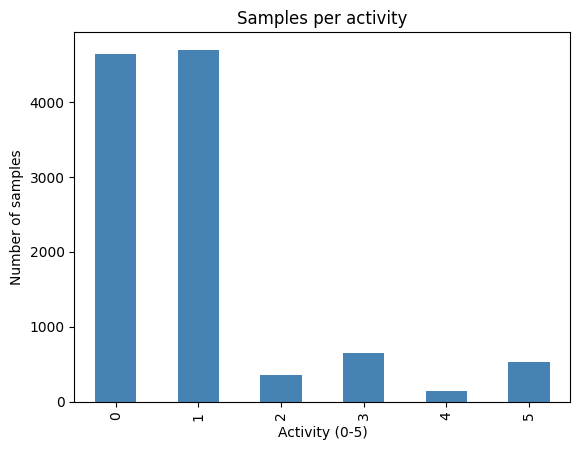

In [4]:
import matplotlib.pyplot as plt

meta_df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Samples per activity')
plt.xlabel('Activity (0-5)')
plt.ylabel('Number of samples')
plt.show()


# Naive Baseline Methods Performance

In [5]:
import pandas as pd
import glob
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

def load_dataset(folder):
    all_files = glob.glob(f"{folder}/**/*.csv", recursive=True)
    samples = []
    
    for filepath in all_files:
        df = pd.read_csv(filepath)
        file_id = df['file_id'].iloc[0]
        label = df['label'].iloc[0] if 'label' in df.columns else None
        
        features = {}
        for col in ['mean_x','mean_y','mean_z','std_x','std_y','std_z']:
            features[f'{col}_mean']   = df[col].mean()
            features[f'{col}_std']    = df[col].std()
            features[f'{col}_min']    = df[col].min()
            features[f'{col}_max']    = df[col].max()
            features[f'{col}_median'] = df[col].median()
        
        features['file_id'] = file_id
        features['label']   = label
        samples.append(features)
    
    return pd.DataFrame(samples)

train_df = load_dataset("train")

feature_cols = [c for c in train_df.columns 
                if c not in ['file_id','label']]

X = train_df[feature_cols].values
y = train_df['label'].values

# Naive baselines
dummy_most = DummyClassifier(strategy='most_frequent')
score1 = cross_val_score(dummy_most, X, y, cv=5, scoring='f1_macro')
print(f"Baseline 1 (most frequent): F1 = {score1.mean():.4f}")

dummy_random = DummyClassifier(strategy='uniform')
score2 = cross_val_score(dummy_random, X, y, cv=5, scoring='f1_macro')
print(f"Baseline 2 (random):        F1 = {score2.mean():.4f}")

dummy_strat = DummyClassifier(strategy='stratified')
score3 = cross_val_score(dummy_strat, X, y, cv=5, scoring='f1_macro')
print(f"Baseline 3 (stratified):    F1 = {score3.mean():.4f}")


Baseline 1 (most frequent): F1 = 0.0996
Baseline 2 (random):        F1 = 0.1202
Baseline 3 (stratified):    F1 = 0.1701
